In [9]:
# =============================================================
# PINN FOR FUSION CROSS SECTIONS (FINAL STABLE VERSION)
# =============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)

# -----------------------------
# LOAD DATA
# -----------------------------
url = "https://drive.google.com/uc?id=1PS0eB8dx8VMzVvxNUc6wBzsMRkEKJjWI"
df = pd.read_csv(url)

epsilon = 1e-12

# -----------------------------
# FEATURES
# -----------------------------
features = [
    'E c.m.', 'Z1', 'Z2', 'Q ( 2 n )',
    'β P', 'β T', 'R B', 'ħ ω'
]

X = df[features].values.astype(np.float32)
y = df["σ"].values.astype(np.float32)

# log scaling (VERY IMPORTANT)
y_log = np.log(y + 1e-10)

# normalize inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# physics inputs
E_all = df["E c.m."].values.astype(np.float32)
VB_all = df["R B"].values.astype(np.float32)   # if real VB exists replace here
RB_all = df["R B"].values.astype(np.float32)
hw_all = df["ħ ω"].values.astype(np.float32)

# -----------------------------
# DATASET
# -----------------------------
class FusionDataset(Dataset):
    def __init__(self):
        self.X = torch.tensor(X_scaled, dtype=torch.float32)
        self.y = torch.tensor(y_log, dtype=torch.float32)
        self.E = torch.tensor(E_all, dtype=torch.float32)
        self.VB = torch.tensor(VB_all, dtype=torch.float32)
        self.RB = torch.tensor(RB_all, dtype=torch.float32)
        self.hw = torch.tensor(hw_all, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.y[idx],
            self.E[idx],
            self.VB[idx],
            self.RB[idx],
            self.hw[idx]
        )

dataset = FusionDataset()
loader = DataLoader(dataset, batch_size=128, shuffle=True)

# -----------------------------
# WONG FORMULA
# -----------------------------
def log1p_exp(x):
    return torch.where(x > 20, x, torch.log1p(torch.exp(x)))

def wong(E, VB, RB, hw):
    E = torch.clamp(E, min=1e-6)
    C = (RB**2) * hw / (2 * E)
    arg = 2 * np.pi * (E - VB) / hw
    log_term = log1p_exp(arg)
    sigma = 10 * C * log_term
    return sigma

# -----------------------------
# MODEL (correction factor)
# -----------------------------
class PINN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        r = torch.tanh(self.net(x)).squeeze()
        return r

model = PINN(X.shape[1]).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# TRAINING
# -----------------------------
EPOCHS = 300

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb, E, VB, RB, hw in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        E = E.to(DEVICE)
        VB = VB.to(DEVICE)
        RB = RB.to(DEVICE)
        hw = hw.to(DEVICE)

        optimizer.zero_grad()

        # -------------------------
        # FORWARD
        # -------------------------
        r = model(xb)

        sigma_w = wong(E, VB, RB, hw)
        sigma_pred = sigma_w * (1 + r)

        pred_log = torch.log(sigma_pred + 1e-10)

        # -------------------------
        # DATA LOSS
        # -------------------------
        data_loss = nn.MSELoss()(pred_log, yb)

        # -------------------------
        # PHYSICS LOSS 1 (HIGH ENERGY)
        # -------------------------
        mask = (E > VB + 5)

        if mask.sum() > 0:
            phys1 = torch.mean(r[mask]**2)
        else:
            phys1 = torch.tensor(0.0, device=DEVICE)

        # -------------------------
        # PHYSICS LOSS 2 (SMOOTHNESS) — FIXED
        # -------------------------
        xb.requires_grad_(True)

        r2 = model(xb)

        grad = torch.autograd.grad(
            outputs=r2.sum(),
            inputs=xb,
            create_graph=True
        )[0]

        dr_dE = grad[:, 0]   # E is first feature

        phys2 = torch.mean(dr_dE**2)

        # -------------------------
        # TOTAL LOSS
        # -------------------------
        loss = data_loss + 0.1*phys1 + 0.01*phys2

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss {total_loss:.4f}")

# -----------------------------
# EVALUATION
# -----------------------------
model.eval()

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
E_tensor = torch.tensor(E_all, dtype=torch.float32).to(DEVICE)
VB_tensor = torch.tensor(VB_all, dtype=torch.float32).to(DEVICE)
RB_tensor = torch.tensor(RB_all, dtype=torch.float32).to(DEVICE)
hw_tensor = torch.tensor(hw_all, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    r = model(X_tensor)
    sigma_w = wong(E_tensor, VB_tensor, RB_tensor, hw_tensor)
    sigma_pred = sigma_w * (1 + r)

pred = sigma_pred.cpu().numpy()
true = y

r2 = r2_score(true, pred)

print("\n==============================")
print("Final R²:", r2)
print("==============================")

Using: cpu
Epoch 0 | Loss 452.6461
Epoch 20 | Loss 56.0346
Epoch 40 | Loss 45.4454
Epoch 60 | Loss 35.2482
Epoch 80 | Loss 22.0787
Epoch 100 | Loss 14.0577
Epoch 120 | Loss 11.6269
Epoch 140 | Loss 9.4290
Epoch 160 | Loss 10.2652
Epoch 180 | Loss 8.6169
Epoch 200 | Loss 8.4320
Epoch 220 | Loss 8.0198
Epoch 240 | Loss 8.8444
Epoch 260 | Loss 8.8373
Epoch 280 | Loss 8.0798

Final R²: 0.956635594367981


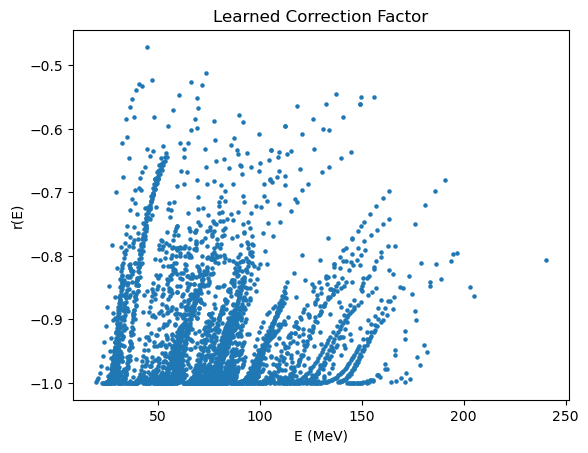

In [10]:
import matplotlib.pyplot as plt

plt.scatter(E_all, r.cpu().numpy(), s=5)
plt.xlabel("E (MeV)")
plt.ylabel("r(E)")
plt.title("Learned Correction Factor")
plt.show()

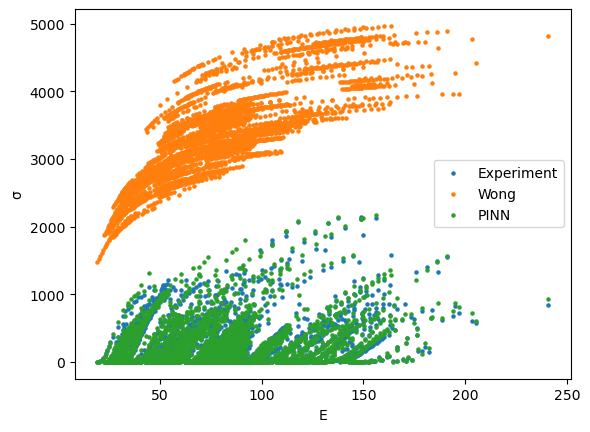

In [11]:
plt.scatter(E_all, y, label="Experiment", s=5)
plt.scatter(E_all, sigma_w.cpu().numpy(), label="Wong", s=5)
plt.scatter(E_all, pred, label="PINN", s=5)
plt.legend()
plt.xlabel("E")
plt.ylabel("σ")
plt.show()

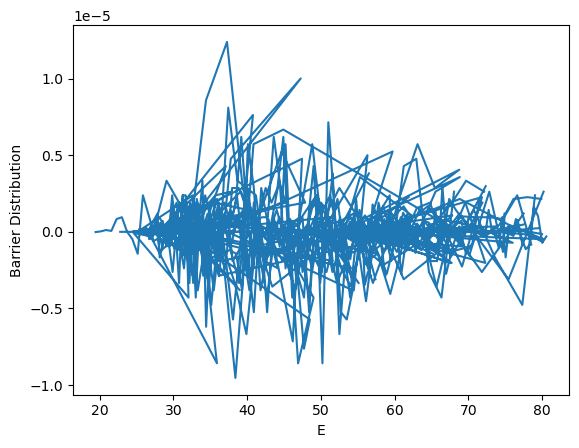

In [12]:
E_t = torch.tensor(E_all, requires_grad=True, dtype=torch.float32).to(DEVICE)

r = model(X_tensor)

sigma = wong(E_t, VB_tensor, RB_tensor, hw_tensor) * (1 + r)

ES = E_t * sigma

d1 = torch.autograd.grad(ES.sum(), E_t, create_graph=True)[0]
d2 = torch.autograd.grad(d1.sum(), E_t)[0]

D = d2.detach().cpu().numpy()

plt.plot(E_all, D)
plt.xlabel("E")
plt.ylabel("Barrier Distribution")
plt.show()

Using: cpu


/tmp/ipykernel_261/104246432.py:68: RuntimeWarning: overflow encountered in exp
  return np.where(x > 50, x, np.log1p(np.exp(x)))


Epoch 0 | Loss 12.1145
Epoch 50 | Loss 0.3226
Epoch 100 | Loss 0.1274
Epoch 150 | Loss 0.1034
Epoch 200 | Loss 0.0859
Epoch 250 | Loss 0.0686
Epoch 300 | Loss 0.0650
Epoch 350 | Loss 0.0591
Epoch 400 | Loss 0.0562
Epoch 450 | Loss 0.0538

Final R²: 0.9804785251617432


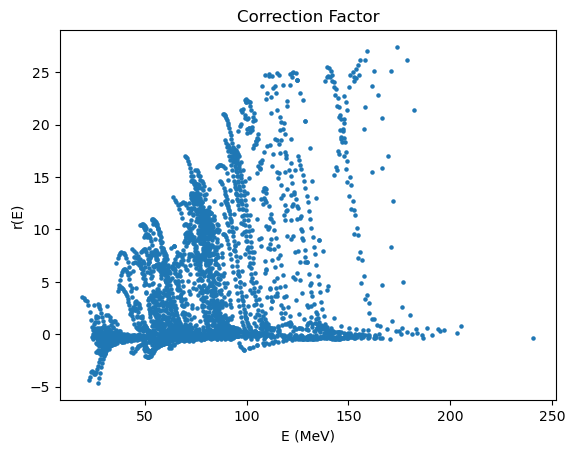

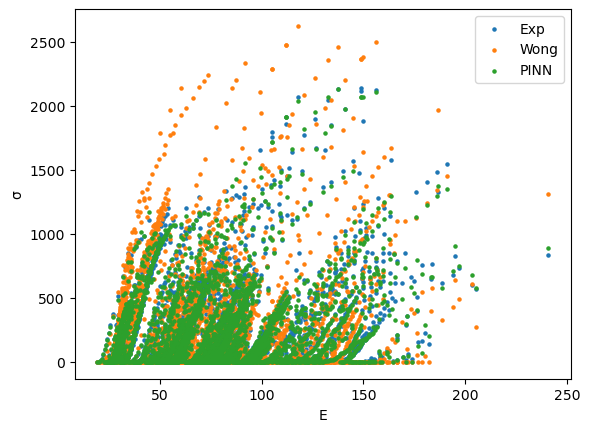

In [19]:
# =============================================================
# FINAL PINN (STABLE + NORMALIZED + NO NaNs)
# =============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)

# -----------------------------
# LOAD DATA
# -----------------------------
url = "https://drive.google.com/uc?id=1PS0eB8dx8VMzVvxNUc6wBzsMRkEKJjWI"
df = pd.read_csv(url)

# Shuffle
df = df.sample(frac=1).reset_index(drop=True)

# -----------------------------
# PHYSICS: BARRIER HEIGHT
# -----------------------------
e2 = 1.44
df["V_B"] = (df["Z1"] * df["Z2"] * e2) / df["R B"]

# -----------------------------
# FEATURES
# -----------------------------
df["Z1Z2_over_Ecm"] = (df["Z1"] * df["Z2"]) / df["E c.m."]

features = [
    'E c.m.',
    'Z1Z2_over_Ecm',
    'Q ( 2 n )',
    'β P',
    'β T',
    'R B',
    'ħ ω'
]

X = df[features].values.astype(np.float32)
y = df["σ"].values.astype(np.float32)

# -----------------------------
# SCALE INPUTS
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# PHYSICS INPUTS
# -----------------------------
E_all = df["E c.m."].values.astype(np.float32)
VB_all = df["V_B"].values.astype(np.float32)
RB_all = df["R B"].values.astype(np.float32)
hw_all = df["ħ ω"].values.astype(np.float32)

# -----------------------------
# STABLE WONG FUNCTION (NUMERICAL FIX)
# -----------------------------
def stable_log1pexp(x):
    return np.where(x > 50, x, np.log1p(np.exp(x)))

def wong_np(E, VB, RB, hw):
    E = np.clip(E, 1e-6, None)
    C = (RB**2) * hw / (2 * E)
    arg = 2 * np.pi * (E - VB) / hw
    return 10 * C * stable_log1pexp(arg)

# -----------------------------
# COMPUTE RESIDUAL TARGET
# -----------------------------
sigma_w_all = wong_np(E_all, VB_all, RB_all, hw_all)

log_sigma_exp = np.log(y + 1e-10)
log_sigma_w   = np.log(sigma_w_all + 1e-10)

r_target = log_sigma_exp - log_sigma_w

# -----------------------------
# REMOVE NaNs (IMPORTANT)
# -----------------------------
mask = np.isfinite(r_target)

X_scaled = X_scaled[mask]
y = y[mask]
E_all = E_all[mask]
VB_all = VB_all[mask]
RB_all = RB_all[mask]
hw_all = hw_all[mask]
r_target = r_target[mask]

# -----------------------------
# NORMALIZE TARGET (CRITICAL)
# -----------------------------
r_mean = r_target.mean()
r_std  = r_target.std() + 1e-8

r_target_norm = (r_target - r_mean) / r_std

# -----------------------------
# DATASET
# -----------------------------
class FusionDataset(Dataset):
    def __init__(self):
        self.X = torch.tensor(X_scaled, dtype=torch.float32)
        self.y = torch.tensor(r_target_norm, dtype=torch.float32)
        self.E = torch.tensor(E_all, dtype=torch.float32)
        self.VB = torch.tensor(VB_all, dtype=torch.float32)
        self.RB = torch.tensor(RB_all, dtype=torch.float32)
        self.hw = torch.tensor(hw_all, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.E[idx], self.VB[idx], self.RB[idx], self.hw[idx]

dataset = FusionDataset()
loader = DataLoader(dataset, batch_size=128, shuffle=True)

# -----------------------------
# MODEL
# -----------------------------
class PINN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

model = PINN(X_scaled.shape[1]).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=500)

# -----------------------------
# TRAINING
# -----------------------------
EPOCHS = 500

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb, _, _, _, _ in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        r_pred_norm = model(xb)

        loss = nn.MSELoss()(r_pred_norm, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss {total_loss:.4f}")

# -----------------------------
# EVALUATION
# -----------------------------
model.eval()

X_t = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
E_t = torch.tensor(E_all, dtype=torch.float32).to(DEVICE)
VB_t = torch.tensor(VB_all, dtype=torch.float32).to(DEVICE)
RB_t = torch.tensor(RB_all, dtype=torch.float32).to(DEVICE)
hw_t = torch.tensor(hw_all, dtype=torch.float32).to(DEVICE)

def log1p_exp(x):
    return torch.where(x > 20, x, torch.log1p(torch.exp(x)))

def wong(E, VB, RB, hw):
    E = torch.clamp(E, min=1e-6)
    C = (RB**2) * hw / (2 * E)
    arg = 2 * np.pi * (E - VB) / hw
    return 10 * C * log1p_exp(arg)

with torch.no_grad():
    r_pred_norm = model(X_t)

    # de-normalize
    r_pred = r_pred_norm * r_std + r_mean

    sigma_w = wong(E_t, VB_t, RB_t, hw_t)

    sigma_pred = sigma_w * torch.exp(r_pred)

pred = sigma_pred.cpu().numpy()
true = y

print("\nFinal R²:", r2_score(true, pred))

# -----------------------------
# PLOTS
# -----------------------------
plt.scatter(E_all, r_pred.cpu().numpy(), s=5)
plt.xlabel("E (MeV)")
plt.ylabel("r(E)")
plt.title("Correction Factor")
plt.show()

plt.scatter(E_all, true, s=5, label="Exp")
plt.scatter(E_all, sigma_w.cpu().numpy(), s=5, label="Wong")
plt.scatter(E_all, pred, s=5, label="PINN")
plt.legend()
plt.xlabel("E")
plt.ylabel("σ")
plt.show()

In [17]:
best_r2 = -1
best_config = None

for hidden in [128, 256, 512]:
    for lr in [1e-3, 5e-4]:
        print(f"\nTrying hidden={hidden}, lr={lr}")

        _, _, _, r2_val = train_model(hidden=hidden, lr=lr)

        if r2_val > best_r2:
            best_r2 = r2_val
            best_config = (hidden, lr)

print("\nBest R²:", best_r2)
print("Best config:", best_config)


Trying hidden=128, lr=0.001
Epoch 0 | Loss 1503.4000
Epoch 50 | Loss 1455.0740
Epoch 100 | Loss 1448.1420
Epoch 150 | Loss 1454.5643

Trying hidden=128, lr=0.0005
Epoch 0 | Loss 1536.2360
Epoch 50 | Loss 1456.6456
Epoch 100 | Loss 1456.6659
Epoch 150 | Loss 1452.6057

Trying hidden=256, lr=0.001
Epoch 0 | Loss 1485.7447
Epoch 50 | Loss 1447.2948
Epoch 100 | Loss 1449.5787
Epoch 150 | Loss 1455.1239

Trying hidden=256, lr=0.0005
Epoch 0 | Loss 1505.5284
Epoch 50 | Loss 1465.5328
Epoch 100 | Loss 1444.4877
Epoch 150 | Loss 1452.2487

Trying hidden=512, lr=0.001
Epoch 0 | Loss 1471.1782
Epoch 50 | Loss 1450.5240
Epoch 100 | Loss 1446.2390
Epoch 150 | Loss 1448.2077

Trying hidden=512, lr=0.0005
Epoch 0 | Loss 1474.7719
Epoch 50 | Loss 1455.4694
Epoch 100 | Loss 1450.8294
Epoch 150 | Loss 1454.0096

Best R²: 0.8918206691741943
Best config: (512, 0.001)


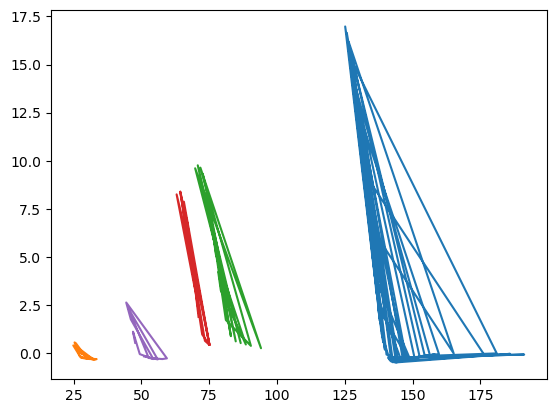

In [20]:
for reaction in df["Reaction"].unique()[:5]:
    sub = df[df["Reaction"] == reaction]

    E = sub["E c.m."]
    r_sub = r_pred.cpu().numpy()[sub.index]

    plt.plot(E, r_sub)

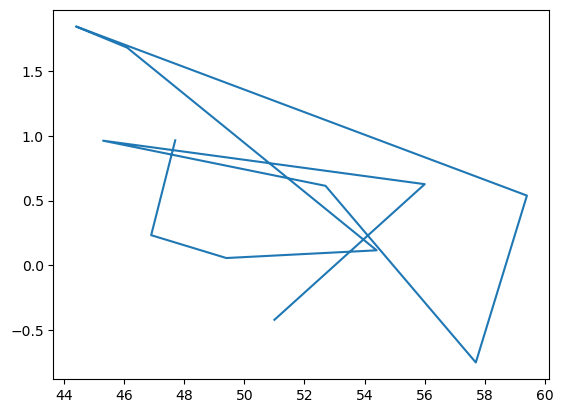

In [21]:
from scipy.signal import savgol_filter

r_smooth = savgol_filter(r_sub, 5, 2)
plt.plot(E, r_smooth)

In [25]:
# =============================================================
# PINN WITH STRUCTURE-AWARE FEATURES (PRC-LEVEL VERSION)
# =============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from pathlib import Path
import random

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -----------------------------
# CONFIG
# -----------------------------
OUTDIR_BASE = "mdn_70_10_20_optimized"
BATCH_SIZE = 128
MAX_EPOCHS = 500
PATIENCE = 30
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# -----------------------------
# LOAD DATA
# -----------------------------
url = "https://drive.google.com/uc?id=1PS0eB8dx8VMzVvxNUc6wBzsMRkEKJjWI"
df = pd.read_csv(url)

# -----------------------------
# REACTION SPLIT
# -----------------------------
train_file = Path(OUTDIR_BASE) / "train_reactions.csv"
val_file   = Path(OUTDIR_BASE) / "val_reactions.csv"
test_file  = Path(OUTDIR_BASE) / "test_reactions.csv"

if train_file.exists():
    train_reacts = pd.read_csv(train_file)["Reaction"].values
    val_reacts   = pd.read_csv(val_file)["Reaction"].values
    test_reacts  = pd.read_csv(test_file)["Reaction"].values
else:
    reactions = df["Reaction"].unique()
    np.random.shuffle(reactions)
    n = len(reactions)
    train_reacts = reactions[:int(0.7*n)]
    val_reacts   = reactions[int(0.7*n):int(0.8*n)]
    test_reacts  = reactions[int(0.8*n):]

train_mask = df["Reaction"].isin(train_reacts)
val_mask   = df["Reaction"].isin(val_reacts)
test_mask  = df["Reaction"].isin(test_reacts)

print("Train:", train_mask.sum(), "Val:", val_mask.sum(), "Test:", test_mask.sum())

# -----------------------------
# PHYSICS FEATURES
# -----------------------------
e2 = 1.44
df["V_B"] = (df["Z1"] * df["Z2"] * e2) / df["R B"]

# 🔥 CRITICAL FEATURES
df["x"] = df["E c.m."] / df["V_B"]                # scaled energy
df["Z1Z2_over_Ecm"] = (df["Z1"] * df["Z2"]) / df["E c.m."]
df["beta_eff"] = (df["β P"] + df["β T"]) / 2
df["asym"] = np.abs(df["A1"] - df["A2"]) / (df["A1"] + df["A2"])

features = [
    'x',
    'Z1Z2_over_Ecm',
    'beta_eff',
    'Q ( 2 n )',
    'R B',
    'ħ ω',
    'asym'
]

# -----------------------------
# EXTRACT ARRAYS
# -----------------------------
X_all = df[features].values.astype(np.float32)
sigma_all = df["σ"].values.astype(np.float32)

E_all = df["E c.m."].values.astype(np.float32)
VB_all = df["V_B"].values.astype(np.float32)
RB_all = df["R B"].values.astype(np.float32)
hw_all = df["ħ ω"].values.astype(np.float32)

# -----------------------------
# SCALE INPUTS (TRAIN ONLY)
# -----------------------------
scaler = StandardScaler()
scaler.fit(X_all[train_mask])
X_scaled = scaler.transform(X_all)

# -----------------------------
# STABLE WONG
# -----------------------------
def stable_log1pexp(x):
    return np.where(x > 50, x, np.log1p(np.exp(x)))

def wong_np(E, VB, RB, hw):
    E = np.clip(E, 1e-6, None)
    C = (RB**2) * hw / (2 * E)
    arg = 2 * np.pi * (E - VB) / hw
    return 10 * C * stable_log1pexp(arg)

sigma_w = wong_np(E_all, VB_all, RB_all, hw_all)

# -----------------------------
# RESIDUAL TARGET
# -----------------------------
log_sigma_exp = np.log(sigma_all + 1e-10)
log_sigma_w   = np.log(sigma_w + 1e-10)

r_target = log_sigma_exp - log_sigma_w

# -----------------------------
# CLEAN NaNs
# -----------------------------
mask = np.isfinite(r_target)
X_scaled = X_scaled[mask]
r_target = r_target[mask]
sigma_all = sigma_all[mask]
E_all = E_all[mask]
VB_all = VB_all[mask]
RB_all = RB_all[mask]
hw_all = hw_all[mask]

train_mask = train_mask[mask]
val_mask   = val_mask[mask]
test_mask  = test_mask[mask]

# -----------------------------
# NORMALIZE TARGET (TRAIN ONLY)
# -----------------------------
r_mean = r_target[train_mask].mean()
r_std  = r_target[train_mask].std() + 1e-8

r_norm = (r_target - r_mean) / r_std

# -----------------------------
# DATASET
# -----------------------------
class FusionDataset(Dataset):
    def __init__(self, indices):
        self.idx = indices
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        return (
            X_scaled[j],
            r_norm[j],
            E_all[j],
            VB_all[j],
            RB_all[j],
            hw_all[j],
            sigma_all[j]
        )

train_idx = np.where(train_mask)[0]
val_idx   = np.where(val_mask)[0]
test_idx  = np.where(test_mask)[0]

train_loader = DataLoader(FusionDataset(train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(FusionDataset(val_idx), batch_size=BATCH_SIZE)
test_loader  = DataLoader(FusionDataset(test_idx), batch_size=BATCH_SIZE)

# -----------------------------
# MODEL
# -----------------------------
class PINN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze()

model = PINN(len(features)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

# -----------------------------
# TRAINING
# -----------------------------
best_val = float('inf')
patience = 0
best_state = None

for epoch in range(MAX_EPOCHS):
    model.train()
    train_loss = 0

    for xb, yb, *_ in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        pred = model(xb)
        loss = nn.MSELoss()(pred, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(xb)

    train_loss /= len(train_loader.dataset)

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb, *_ in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += nn.MSELoss()(model(xb), yb).item() * len(xb)

    val_loss /= len(val_loader.dataset)
    scheduler.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = model.state_dict()
        patience = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print("Early stopping")
            break

model.load_state_dict(best_state)
model.eval()

# -----------------------------
# TEST EVALUATION
# -----------------------------
def wong_torch(E, VB, RB, hw):
    E = torch.clamp(E, min=1e-6)
    C = (RB**2) * hw / (2 * E)
    arg = 2 * np.pi * (E - VB) / hw
    return 10 * C * torch.where(arg > 20, arg, torch.log1p(torch.exp(arg)))

preds, trues = [], []

with torch.no_grad():
    for xb, _, Eb, VBb, RBb, hwb, sigma_true in test_loader:
        xb = xb.to(DEVICE)
        Eb, VBb, RBb, hwb = Eb.to(DEVICE), VBb.to(DEVICE), RBb.to(DEVICE), hwb.to(DEVICE)

        r = model(xb) * r_std + r_mean
        sigma_w = wong_torch(Eb, VBb, RBb, hwb)
        sigma_pred = sigma_w * torch.exp(r)

        preds.append(sigma_pred.cpu().numpy())
        trues.append(sigma_true)

preds = np.concatenate(preds)
trues = np.concatenate(trues)

print("\nTEST RESULTS")
print("R² =", r2_score(trues, preds))
print("RMSE =", np.sqrt(np.mean((preds - trues)**2)))

Using device: cpu
Train: 2493 Val: 354 Test: 685
Epoch 0 | Train 0.5746 | Val 0.5655


/tmp/ipykernel_261/4112560560.py:107: RuntimeWarning: overflow encountered in exp
  return np.where(x > 50, x, np.log1p(np.exp(x)))


Epoch 50 | Train 0.0267 | Val 0.0792
Epoch 100 | Train 0.0118 | Val 0.0463
Epoch 150 | Train 0.0077 | Val 0.0381
Epoch 200 | Train 0.0048 | Val 0.0325
Epoch 250 | Train 0.0043 | Val 0.0269
Early stopping

TEST RESULTS
R² = 0.7453789710998535
RMSE = 147.52943


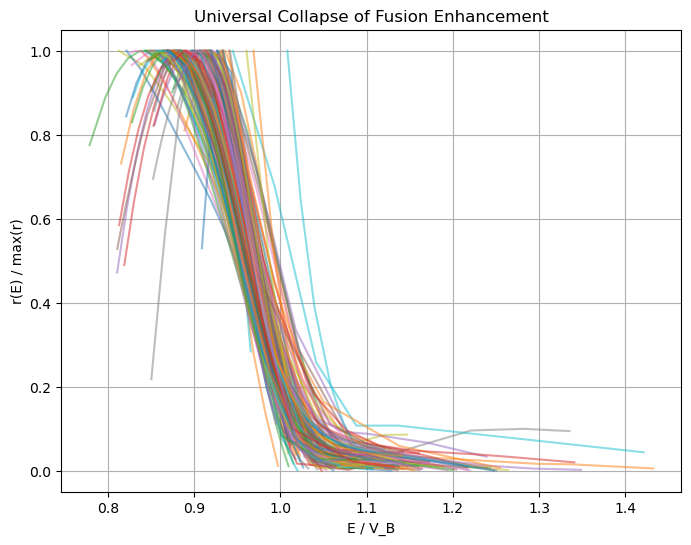

In [26]:
# =============================================================
# UNIVERSAL COLLAPSE ANALYSIS
# =============================================================

import matplotlib.pyplot as plt

# --- Get full predictions (NOT only test, use all data) ---
model.eval()

X_t = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
E_t = torch.tensor(E_all, dtype=torch.float32).to(DEVICE)
VB_t = torch.tensor(VB_all, dtype=torch.float32).to(DEVICE)
RB_t = torch.tensor(RB_all, dtype=torch.float32).to(DEVICE)
hw_t = torch.tensor(hw_all, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    r_pred_norm = model(X_t)
    r_pred = (r_pred_norm * r_std + r_mean).cpu().numpy()

# attach to dataframe (aligned after masking!)
df_clean = df.iloc[np.where(mask)[0]].copy()
df_clean["r"] = r_pred

# ----------------------------------------------------------
# COLLAPSE PLOT
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

for reaction in df_clean["Reaction"].unique():

    sub = df_clean[df_clean["Reaction"] == reaction]

    # sort by energy
    sub = sub.sort_values("E c.m.")

    E = sub["E c.m."].values
    r = sub["r"].values

    # remove invalid / small sets
    if len(r) < 5:
        continue

    # take only positive region (important)
    mask_pos = r > 0
    if mask_pos.sum() < 5:
        continue

    E = E[mask_pos]
    r = r[mask_pos]

    # normalize
    A = np.max(r)
    if A <= 0:
        continue

    r_norm = r / A

    # optional: scale energy by barrier
    VB = sub["V_B"].values[mask_pos]
    x = E / VB

    plt.plot(x, r_norm, alpha=0.5)

plt.xlabel("E / V_B")
plt.ylabel("r(E) / max(r)")
plt.title("Universal Collapse of Fusion Enhancement")
plt.grid(True)
plt.show()

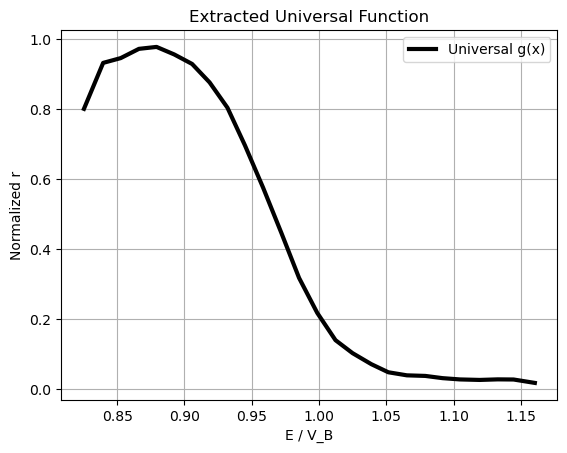

In [27]:
 # =============================================================
# AVERAGE UNIVERSAL CURVE
# =============================================================

all_x = []
all_r = []

for reaction in df_clean["Reaction"].unique():

    sub = df_clean[df_clean["Reaction"] == reaction]
    sub = sub.sort_values("E c.m.")

    E = sub["E c.m."].values
    r = sub["r"].values

    if len(r) < 5:
        continue

    mask_pos = r > 0
    if mask_pos.sum() < 5:
        continue

    E = E[mask_pos]
    r = r[mask_pos]

    A = np.max(r)
    if A <= 0:
        continue

    r_norm = r / A
    VB = sub["V_B"].values[mask_pos]
    x = E / VB

    all_x.append(x)
    all_r.append(r_norm)

# flatten
all_x = np.concatenate(all_x)
all_r = np.concatenate(all_r)

# sort
idx = np.argsort(all_x)
all_x = all_x[idx]
all_r = all_r[idx]

# binning (smooth curve)
bins = np.linspace(all_x.min(), all_x.max(), 50)
digitized = np.digitize(all_x, bins)

x_mean = []
r_mean = []

for i in range(1, len(bins)):
    mask_bin = digitized == i
    if np.sum(mask_bin) > 10:
        x_mean.append(all_x[mask_bin].mean())
        r_mean.append(all_r[mask_bin].mean())

plt.plot(x_mean, r_mean, 'k-', lw=3, label="Universal g(x)")
plt.xlabel("E / V_B")
plt.ylabel("Normalized r")
plt.title("Extracted Universal Function")
plt.legend()
plt.grid(True)
plt.show()

x0 = 0.9667083571946571
delta = 0.026264242212936866


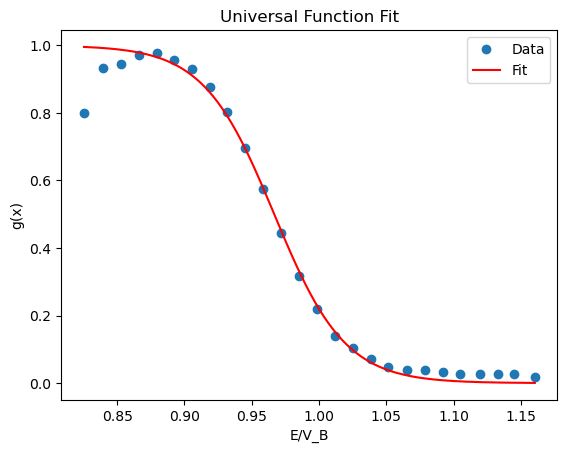

In [28]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# your extracted data
x_data = np.array(x_mean)
y_data = np.array(r_mean)

# logistic model
def logistic(x, x0, delta):
    return 1 / (1 + np.exp((x - x0)/delta))

# fit
popt, _ = curve_fit(logistic, x_data, y_data, p0=[0.95, 0.02])

x0, delta = popt
print("x0 =", x0)
print("delta =", delta)

# plot
x_fit = np.linspace(min(x_data), max(x_data), 200)
y_fit = logistic(x_fit, x0, delta)

plt.plot(x_data, y_data, 'o', label="Data")
plt.plot(x_fit, y_fit, 'r-', label="Fit")
plt.legend()
plt.xlabel("E/V_B")
plt.ylabel("g(x)")
plt.title("Universal Function Fit")
plt.show()

In [29]:
A_values = []
beta_vals = []
Q_vals = []

for reaction in df_clean["Reaction"].unique():
    sub = df_clean[df_clean["Reaction"] == reaction]

    r = sub["r"].values
    if len(r) < 5:
        continue

    A = np.max(r)
    A_values.append(A)

    beta_vals.append(sub["beta_eff"].values[0])
    Q_vals.append(sub["Q ( 2 n )"].values[0])

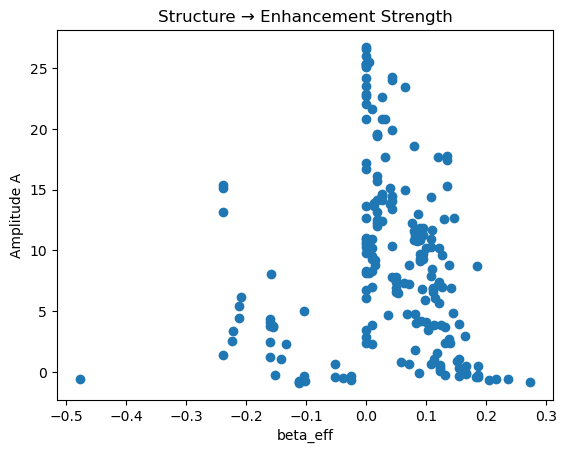

In [30]:
plt.scatter(beta_vals, A_values)
plt.xlabel("beta_eff")
plt.ylabel("Amplitude A")
plt.title("Structure → Enhancement Strength")
plt.show()

In [32]:
# =============================================================
# FINAL MODEL VALIDATION (FIXED ALIGNMENT)
# =============================================================

# Recompute Wong on CLEAN DATA (aligned!)
def wong_np(E, VB, RB, hw):
    E = np.clip(E, 1e-6, None)
    C = (RB**2) * hw / (2 * E)
    arg = 2 * np.pi * (E - VB) / hw
    return 10 * C * np.where(arg > 50, arg, np.log1p(np.exp(arg)))

# Extract aligned arrays
E_clean  = df_clean["E c.m."].values
VB_clean = df_clean["V_B"].values
RB_clean = df_clean["R B"].values
hw_clean = df_clean["ħ ω"].values
sigma_true_clean = df_clean["σ"].values

# Compute Wong correctly aligned
sigma_w_clean = wong_np(E_clean, VB_clean, RB_clean, hw_clean)

# Define universal function
def g_func(x):
    return 1 / (1 + np.exp((x - x0)/delta))

# Compute predictions
sigma_universal = []

for i in range(len(df_clean)):
    x = E_clean[i] / VB_clean[i]
    g = g_func(x)

    reaction = df_clean.iloc[i]["Reaction"]

    sub = df_clean[df_clean["Reaction"] == reaction]
    A = np.max(sub["r"].values)

    sigma_pred = sigma_w_clean[i] * np.exp(A * g)
    sigma_universal.append(sigma_pred)

sigma_universal = np.array(sigma_universal)

# Evaluate
from sklearn.metrics import r2_score
import numpy as np

print("\n========== UNIVERSAL MODEL ==========")
print("R² =", r2_score(sigma_true_clean, sigma_universal))
print("RMSE =", np.sqrt(np.mean((sigma_universal - sigma_true_clean)**2)))


========== UNIVERSAL MODEL ==========
R² = -2.950728133308902
RMSE = 615.0032823658935


In [33]:
# compute optimal A per reaction
def compute_A_opt(sub, x0, delta):
    E = sub["E c.m."].values
    VB = sub["V_B"].values
    r = sub["r"].values

    x = E / VB
    g = 1 / (1 + np.exp((x - x0)/delta))

    numerator = np.sum(r * g)
    denominator = np.sum(g**2) + 1e-8

    return numerator / denominator

In [34]:
sigma_universal = []

for i in range(len(df_clean)):
    reaction = df_clean.iloc[i]["Reaction"]
    sub = df_clean[df_clean["Reaction"] == reaction]

    A = compute_A_opt(sub, x0, delta)

    x = E_clean[i] / VB_clean[i]
    g = 1 / (1 + np.exp((x - x0)/delta))

    sigma_pred = sigma_w_clean[i] * np.exp(A * g)
    sigma_universal.append(sigma_pred)